## Imports

In [17]:
import pennylane as qml
import numpy as np
import random

## Step 0. Settings

In [2]:
data_qubit = 3
ancilla_qubit = 2
n_qubits = data_qubit + ancilla_qubit

In [3]:
dev = qml.device("default.qubit", wires=n_qubits)

## Step 1. Stabilizer Preparation Block 정의

In [10]:
def stabilizer_prep():
    # wires:
    # data: 0,1,2
    # ancilla: 3 (for Z12), 4 (for Z23)

    # --- Z1 Z2 stabilizer ---
    qml.CNOT(wires=[0, 3])
    qml.CNOT(wires=[1, 3])
    qml.CNOT(wires=[0, 3])
    qml.CNOT(wires=[1, 3])

    # --- Z2 Z3 stabilizer ---
    qml.CNOT(wires=[1, 4])
    qml.CNOT(wires=[2, 4])
    qml.CNOT(wires=[1, 4])
    qml.CNOT(wires=[2, 4])

---

## Step 2. Random Clifford 생성

In [13]:
# Primitive gate application
def apply_gate(name, wire):
    if name == "H":
        qml.Hadamard(wires=wire)
    elif name == "S":
        qml.S(wires=wire)
    elif name == "X":
        qml.PauliX(wires=wire)
    elif name == "Y":
        qml.PauliY(wires=wire)
    elif name == "Z":
        qml.PauliZ(wires=wire)

In [14]:
CLIFFORD_SET = [
    [],  # 0: I
    
    ["H"],
    ["S"],
    ["H","S"],
    ["S","H"],
    ["H","S","H"],
    
    ["X"],
    ["Y"],
    ["Z"],
    
    ["X","H"],
    ["Y","H"],
    ["Z","H"],
    
    ["X","S"],
    ["Y","S"],
    ["Z","S"],
    
    ["H","X"],
    ["H","Y"],
    ["H","Z"],
    
    ["S","X"],
    ["S","Y"],
    ["S","Z"],
    
    ["H","S","X"],
    ["H","S","Y"],
    ["H","S","Z"],
]

In [15]:
def apply_clifford(seq, wire):
    for gate in seq:
        apply_gate(gate, wire)

In [16]:
def sample_random_clifford():
    idx = random.randint(0, 23)
    return idx, CLIFFORD_SET[idx]

In [18]:
def apply_gate_inverse(name, wire):
    if name == "H":
        qml.Hadamard(wires=wire)
    elif name == "S":
        qml.adjoint(qml.S)(wires=wire)
    elif name == "X":
        qml.PauliX(wires=wire)
    elif name == "Y":
        qml.PauliY(wires=wire)
    elif name == "Z":
        qml.PauliZ(wires=wire)

def apply_clifford_inverse(seq, wire):
    for gate in reversed(seq):
        apply_gate_inverse(gate, wire)

In [28]:
@qml.qnode(dev)
def test_random_clifford():
    idx, seq = sample_random_clifford()
    print(f"Applying Clifford index: {idx}, sequence: {seq}")
    apply_clifford(seq, wire=0)
    apply_clifford_inverse(seq, wire=0)
    return qml.state()

In [67]:
test_random_clifford()

Applying Clifford index: 1, sequence: ['H']


array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j])

## Step 3. Random Pauli 삽입

In [68]:
PAULI_SET = ["I", "X", "Y", "Z"]

In [69]:
def apply_pauli(name, wire):
    if name == "X":
        qml.PauliX(wires=wire)
    elif name == "Y":
        qml.PauliY(wires=wire)
    elif name == "Z":
        qml.PauliZ(wires=wire)
    # "I"는 아무것도 안 함

In [70]:
import random

def sample_random_pauli():
    idx = random.randint(0, 3)
    return idx, PAULI_SET[idx]

In [71]:
def apply_pauli_inverse(name, wire):
    apply_pauli(name, wire)

In [72]:
@qml.qnode(dev)
def test_pauli():
    idx, p = sample_random_pauli()
    apply_pauli(p, wire=0)
    apply_pauli_inverse(p, wire=0)
    return qml.state()

## Step 4. $m$-round protocol 종합 및 실행

In [97]:
dev = qml.device("default.qubit", wires=5)

DATA_WIRES = [0,1,2]
ANC_WIRES = [3,4]


############################
# Stabilizer Preparation
############################

def stabilizer_prep():
    # Z1 Z2
    qml.CNOT(wires=[0,3])
    qml.CNOT(wires=[1,3])
    qml.CNOT(wires=[0,3])
    qml.CNOT(wires=[1,3])

    # Z2 Z3
    qml.CNOT(wires=[1,4])
    qml.CNOT(wires=[2,4])
    qml.CNOT(wires=[1,4])
    qml.CNOT(wires=[2,4])


############################
# Pauli
############################

PAULI_SET = ["I","X","Y","Z"]

def apply_pauli(name, wire):
    if name == "X":
        qml.PauliX(wires=wire)
    elif name == "Y":
        qml.PauliY(wires=wire)
    elif name == "Z":
        qml.PauliZ(wires=wire)

def sample_random_pauli():
    idx = random.randint(0,3)
    return PAULI_SET[idx]


############################
# Clifford
############################

CLIFFORD_SET = [
    [],
    ["H"], ["S"], ["H","S"], ["S","H"], ["H","S","H"],
    ["X"], ["Y"], ["Z"],
    ["X","H"], ["Y","H"], ["Z","H"],
    ["X","S"], ["Y","S"], ["Z","S"],
    ["H","X"], ["H","Y"], ["H","Z"],
    ["S","X"], ["S","Y"], ["S","Z"],
    ["H","S","X"], ["H","S","Y"], ["H","S","Z"]
]

def apply_gate(name, wire):
    if name == "H":
        qml.Hadamard(wires=wire)
    elif name == "S":
        qml.S(wires=wire)
    elif name == "X":
        qml.PauliX(wires=wire)
    elif name == "Y":
        qml.PauliY(wires=wire)
    elif name == "Z":
        qml.PauliZ(wires=wire)

def apply_gate_inverse(name, wire):
    if name == "S":
        qml.adjoint(qml.S)(wires=wire)
    else:
        apply_gate(name, wire)

def apply_clifford(seq, wire):
    for g in seq:
        apply_gate(g, wire)

def apply_clifford_inverse(seq, wire):
    for g in reversed(seq):
        apply_gate_inverse(g, wire)

def sample_random_clifford():
    idx = random.randint(0,23)
    return CLIFFORD_SET[idx]


############################
# m-round protocol
############################

@qml.qnode(dev)
def run_protocol(m):

    # 기록용
    C0_list = []
    Cj_list = []
    Pj_list = []

    # -------- Initial Clifford --------
    for w in DATA_WIRES:
        seq = sample_random_clifford()
        C0_list.append(seq)
        apply_clifford(seq, w)
    
    qml.Barrier()

    # -------- m rounds --------
    for j in range(m):

        round_cliffords = []
        round_paulis = []

        # random Clifford
        for w in DATA_WIRES:
            seq = sample_random_clifford()
            round_cliffords.append(seq)
            apply_clifford(seq, w)
        qml.Barrier(wires=DATA_WIRES)

        stabilizer_prep()
        qml.Barrier(wires=DATA_WIRES)

        # random Pauli
        for w in DATA_WIRES:
            p = sample_random_pauli()
            round_paulis.append(p)
            apply_pauli(p, w)
        qml.Barrier(wires=DATA_WIRES)

        stabilizer_prep()
        qml.Barrier(wires=DATA_WIRES)

        Cj_list.append(round_cliffords)
        Pj_list.append(round_paulis)

        qml.Barrier()

    # -------- Global inverse --------
    # inverse of rounds (reverse order)
    for j in reversed(range(m)):

        # inverse Pauli
        for w,p in zip(DATA_WIRES, Pj_list[j]):
            apply_pauli(p, w)

        # inverse Clifford
        for w,seq in zip(DATA_WIRES, Cj_list[j]):
            apply_clifford_inverse(seq, w)

    # inverse initial Clifford
    for w,seq in zip(DATA_WIRES, C0_list):
        apply_clifford_inverse(seq, w)

    return qml.probs(wires=DATA_WIRES)

[1. 0. 0. 0. 0. 0. 0. 0.]


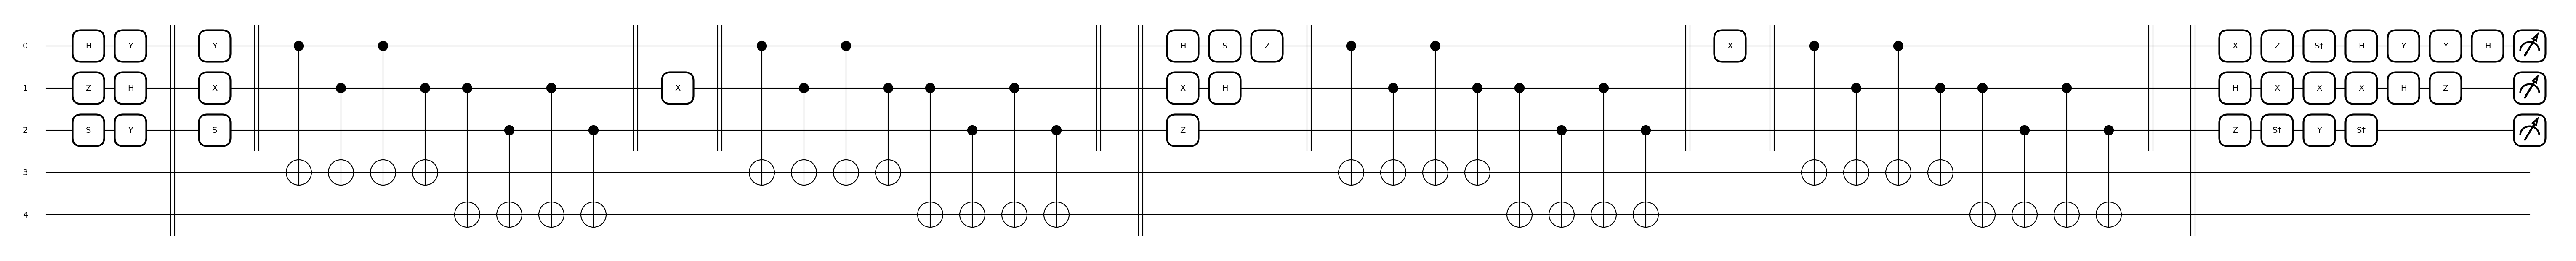

In [98]:
qml.draw_mpl(run_protocol)(m=2)
print(run_protocol(m=3))

## Step 5. Noise 추가

In [139]:
def apply_correlated_noise(p, q, r):

    # single qubit noise
    for w in DATA_WIRES:
        if random.random() < p:
            qml.Barrier(wires=w)
            qml.PauliZ(wires=w)
            qml.Barrier(wires=w)


    # 2-qubit correlated (0,1)
    if random.random() < q:
        qml.Barrier(wires=[0,1])
        qml.PauliZ(wires=0)
        qml.PauliZ(wires=1)
        qml.Barrier(wires=[0,1])

    # 3-qubit correlated
    if random.random() < r:
        qml.Barrier(wires=DATA_WIRES)
        for w in DATA_WIRES:
            qml.PauliZ(wires=w)
        qml.Barrier(wires=DATA_WIRES)

In [182]:
@qml.qnode(dev)
def run_protocol_with_noise(m, p, q, r):

    C0_list = []
    Cj_list = []
    Pj_list = []

    # -----------------------------
    # Initial Clifford Layer
    # -----------------------------
    qml.Barrier(wires=range(5))

    for w in DATA_WIRES:
        seq = sample_random_clifford()
        C0_list.append(seq)
        apply_clifford(seq, w)

    qml.Barrier(wires=range(5))


    # -----------------------------
    # m Rounds
    # -----------------------------
    for j in range(m):

        round_cliffords = []
        round_paulis = []

        # ---- Local Clifford ----
        for w in DATA_WIRES:
            seq = sample_random_clifford()
            round_cliffords.append(seq)
            apply_clifford(seq, w)

        qml.Barrier(wires=range(5))

        # ---- Stabilizer Prep ----
        stabilizer_prep()

        # ---- Noise ----
        apply_correlated_noise(p,q,r)

        qml.Barrier(wires=range(3))
        # ---- Random Pauli ----
        for w in DATA_WIRES:
            pstr = sample_random_pauli()
            round_paulis.append(pstr)
            apply_pauli(pstr, w)

        qml.Barrier(wires=range(3))

        # ---- Stabilizer Prep ----
        stabilizer_prep()

        # ---- Noise ----
        apply_correlated_noise(p,q,r)

        qml.Barrier(wires=range(3))

        Cj_list.append(round_cliffords)
        Pj_list.append(round_paulis)


    # -----------------------------
    # Global Inverse
    # -----------------------------

    for j in reversed(range(m)):

        # inverse Pauli
        for w,pstr in zip(DATA_WIRES, Pj_list[j]):
            apply_pauli(pstr, w)

        # inverse Clifford
        for w,seq in zip(DATA_WIRES, Cj_list[j]):
            apply_clifford_inverse(seq, w)

        qml.Barrier(wires=range(5))

    # inverse initial Clifford
    for w,seq in zip(DATA_WIRES, C0_list):
        apply_clifford_inverse(seq, w)

    qml.Barrier(wires=range(5))

    return qml.probs(wires=DATA_WIRES)

(<Figure size 4100x600 with 1 Axes>, <Axes: >)

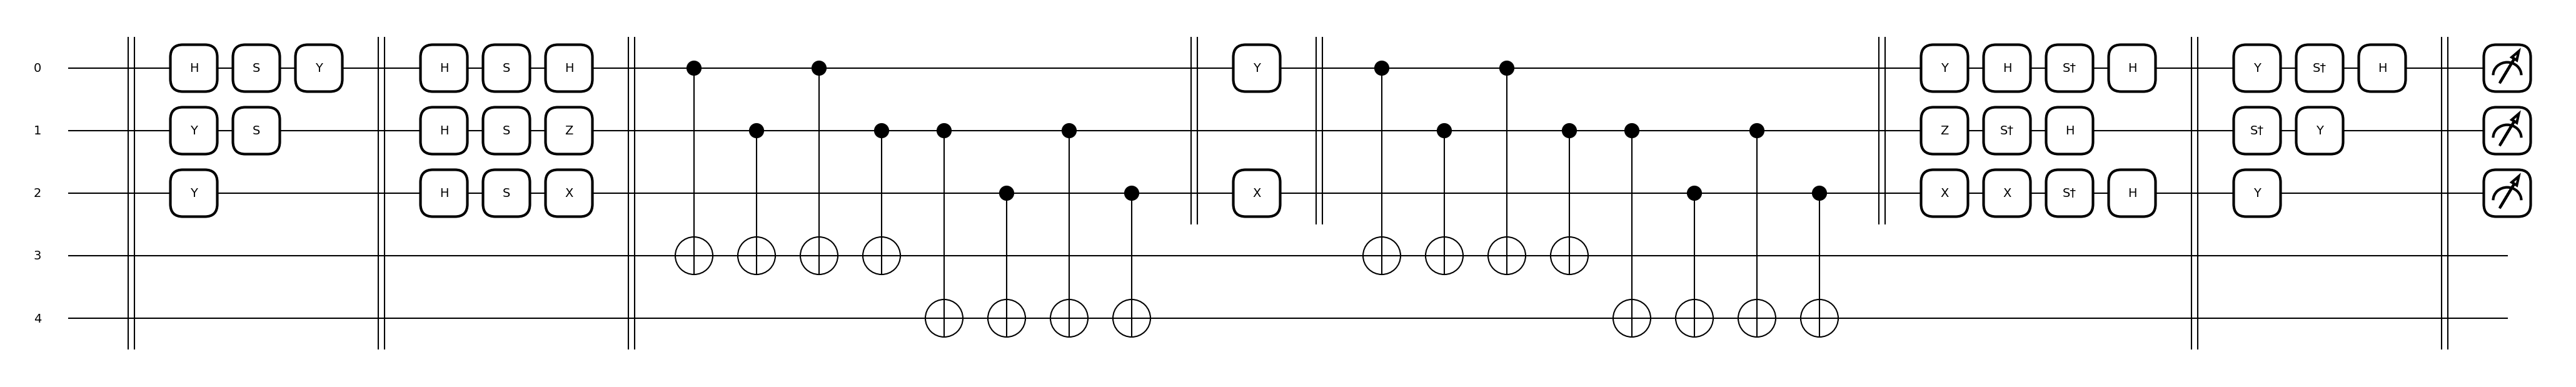

In [183]:
qml.draw_mpl(run_protocol_with_noise)(m=1, p=0.02, q=0.01, r=0.005)

In [ ]:
def compute_Z1_expectation(probs):
    exp = 0
    for i, p in enumerate(probs):
        bitstring = format(i, "03b")
        if bitstring[0] == "0":
            exp += p
        else:
            exp -= p
    return exp

In [124]:
m_values = [1,2,3,4,5]
p,q,r = 0.02, 0.01, 0.005

for m in m_values:
    exp_avg = 0
    shots = 200

    for _ in range(shots):
        probs = run_protocol_with_noise(m,p,q,r)
        exp_avg += compute_Z1_expectation(probs)

    exp_avg /= shots
    print(m, exp_avg)

1 0.9599999999999999
2 0.8899999999999997
3 0.7699999999999996
4 0.6599999999999995
5 0.619999999999999


In [ ]:
def compute_all_Z_expectations(probs):

    results = {}

    for mask in range(8):

        exp = 0.0

        for idx, p in enumerate(probs):

            bitstring = format(idx, "03b")[::-1]  # ← 핵심 수정

            parity = 0
            for q in range(3):
                if (mask >> q) & 1:
                    parity ^= int(bitstring[q])

            sign = 1 if parity == 0 else -1
            exp += sign * p

        results[mask] = exp

    return results

In [128]:
def estimate_all_expectations(m, shots, p, q, r):

    avg = {mask: 0.0 for mask in range(8)}

    for _ in range(shots):

        probs = run_protocol_with_noise(m, p, q, r)
        exp_dict = compute_all_Z_expectations(probs)

        for mask in range(8):
            avg[mask] += exp_dict[mask]

    for mask in range(8):
        avg[mask] /= shots

    return avg

In [ ]:
def pretty_print_expectations(exp_dict):
    for mask, val in exp_dict.items():
        label = format(mask, "03b")
        print(f"Z^{label}  :  {val:.6f}")

In [184]:
m = 1
exp_avg = estimate_all_expectations(m, 200, p=0.001, q=0.0008, r=0.0005)
pretty_print_expectations(exp_avg)

Z^000  :  1.000000
Z^001  :  1.000000
Z^010  :  0.980000
Z^011  :  0.980000
Z^100  :  1.000000
Z^101  :  1.000000
Z^110  :  0.980000
Z^111  :  0.980000


In [185]:
m = 2
exp_avg = estimate_all_expectations(m, 200, p=0.001, q=0.0008, r=0.0005)
pretty_print_expectations(exp_avg)

Z^000  :  1.000000
Z^001  :  1.000000
Z^010  :  0.990000
Z^011  :  0.990000
Z^100  :  0.990000
Z^101  :  0.990000
Z^110  :  0.980000
Z^111  :  0.980000


In [134]:
m = 3
exp_avg = estimate_all_expectations(m, 200, p=0.001, q=0.0008, r=0.0005)
pretty_print_expectations(exp_avg)

Z^000  :  1.000000
Z^001  :  0.990000
Z^010  :  0.990000
Z^011  :  0.980000
Z^100  :  0.980000
Z^101  :  0.970000
Z^110  :  0.970000
Z^111  :  0.960000


In [186]:
m = 4
exp_avg = estimate_all_expectations(m, 200, p=0.001, q=0.0008, r=0.0005)
pretty_print_expectations(exp_avg)

Z^000  :  1.000000
Z^001  :  0.950000
Z^010  :  0.960000
Z^011  :  0.950000
Z^100  :  0.950000
Z^101  :  0.960000
Z^110  :  0.950000
Z^111  :  0.920000


## 